In [9]:
import numpy as np 
import pandas as pd 
from matplotlib import pyplot as plt

data = pd.read_csv("mnist_train.csv")
data2 = pd.read_csv("mnist_test.csv")

In [10]:
data2.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [108]:
data = np.array(data)
m , n = data.shape
np.random.shuffle(data)

data_dev = data[0:1000].T
Y_dev = data_dev[0]
X_dev = data_dev[1:n]/ 255.0

data_train = data[1000:m].T
Y_train = data_train[0]
X_train = data_train[1:n]/255.0

def init_params():
    W1 = np.random.rand(10,784)- 0.5
    B1 = np.random.rand(10,1)- 0.5
    W2 = np.random.rand(10,10)- 0.5
    B2 = np.random.rand(10,1)- 0.5
    return W1, B1, W2, B2
def ReLU (Z):
    return np.maximum(0,Z)
def softmax(Z):
    expZ = np.exp(Z - np.max(Z, axis=0, keepdims=True))  # stability
    return expZ / np.sum(expZ, axis=0, keepdims=True)
    
def forward_propagation(W1, B1, W2, B2,X):
    Z1 = W1.dot(X) + B1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + B2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

def one_hot (Y):
    one_hot_Y = np.zeros((Y.size, Y.max()+ 1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T
    return one_hot_Y
        
def deriv_ReLU (Z):
    return Z > 0
        
def backward_propagation(W2,Z1, A1, Z2, A2, X, Y):
    one_hot_Y = one_hot(Y)
    m = Y.size
    dZ2 = A2 - one_hot_Y
    dW2 = 1/ m * dZ2.dot(A1.T)
    dB2 = 1/m * np.sum(dZ2, axis=1, keepdims=True)
    dZ1 = W2.T.dot(dZ2) * deriv_ReLU(Z1)
    dW1 = 1/m * dZ1.dot(X.T)
    dB1 = 1/m * np.sum(dZ1, axis=1, keepdims=True)
    return dW1, dB1 , dW2, dB2

def update_params(W1, B1, W2, B2, dW1, dW2 , dB1, dB2, alpha):
    W1 -= alpha * dW1
    B1 -= alpha * dB1
    W2 -= alpha * dW2
    B2 -= alpha * dB2
    return W1, B1, W2, B2
    
def get_predictions(A2):
    return np.argmax(A2, 0)
    
def get_accuracy(predictions, Y ):
    print(predictions, Y)
    return np.sum(predictions == Y) / Y.size
    

def gradient_descent(X, Y , iterations, alpha):
    W1 , B1 , W2 , B2 = init_params()
    for i in range(iterations):
        Z1, A1 , Z2 , A2 = forward_propagation(W1, B1, W2, B2 , X)
        dW1, dB1 , dW2, dB2 = backward_propagation(W2,Z1, A1, Z2, A2, X, Y)
        W1, B1, W2, B2 = update_params(W1, B1, W2, B2, dW1, dW2 , dB1, dB2, alpha)
        if (i % 50 == 0):
            print("Iterations: ",i)
            print("Accuracy: ", get_accuracy(get_predictions(A2), Y))
    return W1, B1, W2, B2
        
    

In [110]:
W1, B1, W2, B2 = gradient_descent(X_train, Y_train, 1000, 0.1)

Iterations:  0
[2 3 3 ... 2 3 2] [0 3 7 ... 7 1 8]
Accuracy:  0.09564406779661017
Iterations:  50
[5 3 9 ... 7 1 8] [0 3 7 ... 7 1 8]
Accuracy:  0.48240677966101697
Iterations:  100
[3 3 9 ... 7 1 8] [0 3 7 ... 7 1 8]
Accuracy:  0.6476610169491526
Iterations:  150
[5 3 7 ... 7 1 8] [0 3 7 ... 7 1 8]
Accuracy:  0.7224915254237289
Iterations:  200
[5 3 7 ... 7 1 8] [0 3 7 ... 7 1 8]
Accuracy:  0.7671864406779662
Iterations:  250
[5 3 7 ... 7 1 8] [0 3 7 ... 7 1 8]
Accuracy:  0.7956440677966101
Iterations:  300
[5 3 7 ... 7 1 8] [0 3 7 ... 7 1 8]
Accuracy:  0.8152372881355933
Iterations:  350
[5 3 7 ... 7 1 8] [0 3 7 ... 7 1 8]
Accuracy:  0.8293559322033899
Iterations:  400
[5 3 7 ... 7 1 8] [0 3 7 ... 7 1 8]
Accuracy:  0.8393389830508474
Iterations:  450
[5 3 7 ... 7 1 8] [0 3 7 ... 7 1 8]
Accuracy:  0.8471525423728814
Iterations:  500
[5 3 7 ... 7 1 8] [0 3 7 ... 7 1 8]
Accuracy:  0.8532033898305085
Iterations:  550
[5 3 7 ... 7 1 8] [0 3 7 ... 7 1 8]
Accuracy:  0.8587118644067797
Itera

In [111]:
def make_predictions(X, W1, B1, W2, B2):
    _, _, _, A2 = forward_propagation(W1, B1, W2, B2, X)
    predictions = get_predictions(A2)
    return predictions
def test_prediction(index, W1, B1, W2, B2):
    current_image = X_train[:, index, None]
    prediction = make_predictions(X_train[:, index,None],W1, B1, W2, B2)
    label = Y_train[index]
    print("prediction: ", prediction)
    print("Label: ", label)

    current_image = current_image.reshape((28,28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation = 'nearest')
    plt.show()

prediction:  [3]
Label:  2


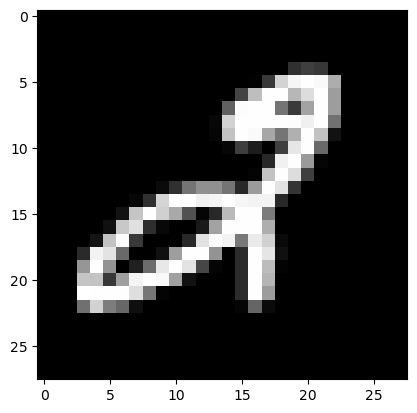

In [121]:
test_prediction(14110, W1, B1, W2, B2)